In [1]:
pip install numpy matplotlib scipy ipykernel



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:

import sys
sys.path.insert(0, "../src")
import jssp_fuzzy_ga.core as core_mod

print("Loaded from:", core_mod.__file__)
print("Has make_instance:", hasattr(core_mod, "make_instance"))

Loaded from: /Users/krrishts/Documents/Fuzzy-mutation-GA/fuzzy-ga/notebooks/../src/jssp_fuzzy_ga/core.py
Has make_instance: True


In [3]:
import numpy as np
from jssp_fuzzy_ga.core import make_instance, FT06_OPTIMUM

inst = make_instance("ft06")
rng = np.random.default_rng(0)
chrom = inst.random_chromosome(rng)

print("chromosome length:", len(chrom), "| expected:", inst.chrom_len)
print("chromosome:", chrom)


chromosome length: 36 | expected: 36
chromosome: [0 5 5 0 0 3 4 3 1 0 0 3 4 1 1 1 5 3 1 2 3 2 5 2 1 0 2 4 2 4 4 3 4 5 2 5]


In [4]:
print("n_jobs:", inst.n_jobs)
print("n_ops_per_job:", inst.n_ops_per_job)
print("chrom_len:", inst.chrom_len)
print("n_machines:", inst.n_machines)

n_jobs: 6
n_ops_per_job: [6, 6, 6, 6, 6, 6]
chrom_len: 36
n_machines: 6


In [5]:
genes_before = []
for j, n_ops in enumerate(inst.n_ops_per_job):
    genes_before += [j] * n_ops
print("before shuffle:", genes_before)

rng2 = np.random.default_rng(0)
chrom2 = inst.random_chromosome(rng2)
print("after shuffle: ", chrom2.tolist())

before shuffle: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5]
after shuffle:  [0, 5, 5, 0, 0, 3, 4, 3, 1, 0, 0, 3, 4, 1, 1, 1, 5, 3, 1, 2, 3, 2, 5, 2, 1, 0, 2, 4, 2, 4, 4, 3, 4, 5, 2, 5]


In [6]:
def decode_verbose(inst, chromosome, max_steps=12):
    next_op = [0] * inst.n_jobs
    machine_free = [0] * inst.n_machines
    job_free = [0] * inst.n_jobs
    for step, gene in enumerate(chromosome):
        j = int(gene)
        op_idx = next_op[j]
        m, dur = inst.jobs[j][op_idx]
        start = max(machine_free[m], job_free[j])
        finish = start + dur
        machine_free[m] = finish
        job_free[j] = finish
        next_op[j] += 1
        if step < max_steps:
            print(f"step {step:2d}: job {j} op {op_idx} -> machine {m} (dur {dur}) | starts {start}, finishes {finish}")
    return max(job_free)

makespan = decode_verbose(inst, chrom)
print("\nfinal makespan:", makespan)

step  0: job 0 op 0 -> machine 2 (dur 1) | starts 0, finishes 1
step  1: job 5 op 0 -> machine 1 (dur 3) | starts 0, finishes 3
step  2: job 5 op 1 -> machine 3 (dur 3) | starts 3, finishes 6
step  3: job 0 op 1 -> machine 0 (dur 3) | starts 1, finishes 4
step  4: job 0 op 2 -> machine 1 (dur 6) | starts 4, finishes 10
step  5: job 3 op 0 -> machine 1 (dur 5) | starts 10, finishes 15
step  6: job 4 op 0 -> machine 2 (dur 9) | starts 1, finishes 10
step  7: job 3 op 1 -> machine 0 (dur 5) | starts 15, finishes 20
step  8: job 1 op 0 -> machine 1 (dur 8) | starts 15, finishes 23
step  9: job 0 op 3 -> machine 3 (dur 7) | starts 10, finishes 17
step 10: job 0 op 4 -> machine 5 (dur 3) | starts 17, finishes 20
step 11: job 3 op 2 -> machine 2 (dur 5) | starts 20, finishes 25

final makespan: 87


In [7]:
from jssp_fuzzy_ga.core import tournament_select, pox_crossover, swap_mutation, population_diversity


In [8]:
# build a tiny fake population + fitness to test selection in isolation
pop_test = [inst.random_chromosome(np.random.default_rng(i)) for i in range(5)]
fitness_test = [inst.decode(c) for c in pop_test]
print("fitnesses:", fitness_test)

winner = tournament_select(pop_test, fitness_test, np.random.default_rng(0), k=3)
print("winner makespan:", inst.decode(winner))

fitnesses: [87, 98, 85, 82, 89]
winner makespan: 82


In [9]:
rng_demo = np.random.default_rng(0)
idx_shown = rng_demo.integers(0, len(pop_test), size=3)
print("indices drawn into this tournament:", idx_shown)
print("their fitnesses:", [fitness_test[i] for i in idx_shown])

indices drawn into this tournament: [4 3 2]
their fitnesses: [89, 82, 85]


In [10]:
p1 = inst.random_chromosome(np.random.default_rng(1))
p2 = inst.random_chromosome(np.random.default_rng(2))
child = pox_crossover(p1, p2, inst.n_jobs, np.random.default_rng(0))

print("parent1:", p1)
print("parent2:", p2)
print("child:  ", child)

import collections
print("child gene counts:", collections.Counter(child.tolist()))

parent1: [1 0 1 1 5 0 4 2 2 3 2 0 1 4 3 3 5 4 4 5 5 2 3 5 4 0 4 2 1 3 0 0 1 5 3 2]
parent2: [4 5 2 1 0 3 1 4 4 2 4 1 2 3 2 4 5 3 5 0 3 1 2 0 0 2 3 1 0 3 5 4 5 5 1 0]
child:   [4 5 2 1 0 1 4 4 2 3 4 1 2 2 3 3 4 5 5 0 1 2 3 0 0 2 1 0 5 3 4 5 5 1 3 0]
child gene counts: Counter({4: 6, 5: 6, 2: 6, 1: 6, 0: 6, 3: 6})


In [11]:
n_jobs = inst.n_jobs
jobs_shuffled = np.arange(n_jobs)
rng_demo = np.random.default_rng(0)
rng_demo.shuffle(jobs_shuffled)
split = rng_demo.integers(1, n_jobs)
j1 = set(jobs_shuffled[:split].tolist())

print("shuffled job order:", jobs_shuffled)
print("split point:", split)
print("jobs taken from parent1 (j1):", j1)
print("jobs taken from parent2 (the rest):", set(range(n_jobs)) - j1)

shuffled job order: [3 2 5 4 0 1]
split point: 1
jobs taken from parent1 (j1): {3}
jobs taken from parent2 (the rest): {0, 1, 2, 4, 5}


In [12]:
job_to_check = 3  # the only job taken from parent1

# find every position where job_to_check appears in the child
child_positions = [i for i, g in enumerate(child) if g == job_to_check]
p1_positions = [i for i, g in enumerate(p1) if g == job_to_check]

print(f"positions of job {job_to_check} in child:  ", child_positions)
print(f"positions of job {job_to_check} in parent1:", p1_positions)
print("identical positions?", child_positions == p1_positions)

positions of job 3 in child:   [9, 14, 15, 22, 29, 34]
positions of job 3 in parent1: [9, 14, 15, 22, 29, 34]
identical positions? True


In [13]:
job_to_check2 = 0  # any job NOT in j1

child_seq = [g for g in child if g == job_to_check2]
p2_seq = [g for g in p2 if g == job_to_check2]
print(f"child's job-{job_to_check2} genes, in order: {child_seq}")
print(f"parent2's job-{job_to_check2} genes, in order: {p2_seq}")
# these will trivially match since they're all just job_to_check2 repeated --
# the REAL check is whether the relative ORDER of job {job_to_check2}'s
# operations vs other non-j1 jobs matches parent2's order:
child_non_j1 = [g for g in child if g != job_to_check][:15]
p2_non_j1 = [g for g in p2 if g != job_to_check][:15]
print("\nfirst 15 non-job-3 genes in child: ", child_non_j1)
print("first 15 non-job-3 genes in parent2:", p2_non_j1)
print("match?", child_non_j1 == p2_non_j1)

child's job-0 genes, in order: [0, 0, 0, 0, 0, 0]
parent2's job-0 genes, in order: [0, 0, 0, 0, 0, 0]

first 15 non-job-3 genes in child:  [4, 5, 2, 1, 0, 1, 4, 4, 2, 4, 1, 2, 2, 4, 5]
first 15 non-job-3 genes in parent2: [4, 5, 2, 1, 0, 1, 4, 4, 2, 4, 1, 2, 2, 4, 5]
match? True


In [14]:
rng_mut = np.random.default_rng(0)
original = inst.random_chromosome(np.random.default_rng(5))
mutated = swap_mutation(original, rate=1.0, rng=rng_mut)  # rate=1.0 forces a swap every time

print("original:", original)
print("mutated: ", mutated)
print("same gene counts:", collections.Counter(original.tolist()) == collections.Counter(mutated.tolist()))

diff_positions = [i for i in range(len(original)) if original[i] != mutated[i]]
print("positions that changed:", diff_positions)

original: [2 1 0 1 5 4 2 4 1 3 5 5 1 3 5 5 3 4 0 4 1 4 2 4 0 2 5 3 3 2 3 0 0 2 1 0]
mutated:  [2 1 0 1 5 4 2 4 1 0 5 5 1 3 5 5 3 4 3 4 1 4 2 4 0 2 5 3 3 2 3 0 0 2 1 0]
same gene counts: True
positions that changed: [9, 18]


In [15]:
identical_pop = np.array([inst.random_chromosome(np.random.default_rng(9))] * 5)
print("population (5 copies of the same chromosome):")
print(identical_pop)
print("diversity:", population_diversity(identical_pop))

population (5 copies of the same chromosome):
[[2 3 0 4 2 2 4 3 1 5 1 1 3 4 2 0 4 3 2 5 3 4 1 3 1 0 2 0 0 4 1 5 0 5 5 5]
 [2 3 0 4 2 2 4 3 1 5 1 1 3 4 2 0 4 3 2 5 3 4 1 3 1 0 2 0 0 4 1 5 0 5 5 5]
 [2 3 0 4 2 2 4 3 1 5 1 1 3 4 2 0 4 3 2 5 3 4 1 3 1 0 2 0 0 4 1 5 0 5 5 5]
 [2 3 0 4 2 2 4 3 1 5 1 1 3 4 2 0 4 3 2 5 3 4 1 3 1 0 2 0 0 4 1 5 0 5 5 5]
 [2 3 0 4 2 2 4 3 1 5 1 1 3 4 2 0 4 3 2 5 3 4 1 3 1 0 2 0 0 4 1 5 0 5 5 5]]
diversity: 0.0


In [16]:
varied_pop = np.array([inst.random_chromosome(np.random.default_rng(i)) for i in range(5)])
print("diversity of varied population:", population_diversity(varied_pop))

diversity of varied population: 0.8305555555555555


In [17]:
diffs_matrix = (varied_pop[:, None, :] != varied_pop[None, :, :]).sum(axis=2)
print(diffs_matrix)

iu = np.triu_indices(5, k=1)
print("the 10 unique pairwise diff-counts:", diffs_matrix[iu])
print("their average:", diffs_matrix[iu].mean())
print("divided by 36:", diffs_matrix[iu].mean() / 36)

[[ 0 31 29 27 30]
 [31  0 32 34 29]
 [29 32  0 29 28]
 [27 34 29  0 30]
 [30 29 28 30  0]]
the 10 unique pairwise diff-counts: [31 29 27 30 32 34 29 29 28 30]
their average: 29.9
divided by 36: 0.8305555555555555


In [18]:
import sys
sys.path.insert(0, "../src")
from jssp_fuzzy_ga.fuzzy import memberships

for x in [0.0, 0.25, 0.5, 0.75, 1.0]:
    print(f"x={x}: {memberships(x)}")

x=0.0: {'Low': 1.0, 'Medium': 0.0, 'High': 0.0}
x=0.25: {'Low': 0.5, 'Medium': 0.5, 'High': 0.0}
x=0.5: {'Low': 0.0, 'Medium': 1.0, 'High': 0.0}
x=0.75: {'Low': 0.0, 'Medium': 0.5, 'High': 0.5}
x=1.0: {'Low': 0.0, 'Medium': 0.0, 'High': 1.0}


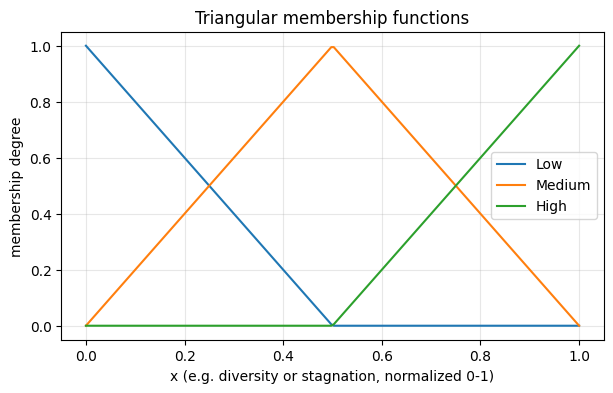

In [19]:
import matplotlib.pyplot as plt

xs = np.linspace(0, 1, 200)
low_vals = [memberships(x)["Low"] for x in xs]
med_vals = [memberships(x)["Medium"] for x in xs]
high_vals = [memberships(x)["High"] for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, low_vals, label="Low")
plt.plot(xs, med_vals, label="Medium")
plt.plot(xs, high_vals, label="High")
plt.xlabel("x (e.g. diversity or stagnation, normalized 0-1)")
plt.ylabel("membership degree")
plt.title("Triangular membership functions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
from jssp_fuzzy_ga.fuzzy import infer

rate, fired = infer(diversity=0.2, stagnation_norm=0.8)
print("mutation rate:", rate)
print("rules that fired:")
for r in fired:
    print(r)

mutation rate: 0.10444444444444445
rules that fired:
{'diversity_term': 'Low', 'diversity_deg': 0.6, 'stagnation_term': 'High', 'stagnation_deg': 0.6000000000000001, 'consequent': 'High', 'strength': 0.6}
{'diversity_term': 'Medium', 'diversity_deg': 0.4, 'stagnation_term': 'High', 'stagnation_deg': 0.6000000000000001, 'consequent': 'High', 'strength': 0.4}
{'diversity_term': 'Low', 'diversity_deg': 0.6, 'stagnation_term': 'Medium', 'stagnation_deg': 0.3999999999999999, 'consequent': 'High', 'strength': 0.3999999999999999}
{'diversity_term': 'Medium', 'diversity_deg': 0.4, 'stagnation_term': 'Medium', 'stagnation_deg': 0.3999999999999999, 'consequent': 'Medium', 'strength': 0.3999999999999999}


In [21]:
from jssp_fuzzy_ga.fuzzy import explain

sentence = explain(generation=5, diversity=0.2, stagnation_norm=0.8, mutation_rate=rate, fired=fired)
print(sentence)

Gen 5: mutation set to 0.104 [raw diversity=0.20, stagnation=0.80] because diversity is Low (0.60) AND stagnation is High (0.60) → mutation should be High (rule strength 0.60); also, diversity is Medium (0.40) AND stagnation is High (0.60) → mutation should be High (rule strength 0.40).


In [22]:
from jssp_fuzzy_ga.experiment import crisp_rate

print("crisp_rate(0.2, 0.8):", crisp_rate(0.2, 0.8))
print("fuzzy infer same inputs:", rate)  # reusing `rate` from your earlier infer() call

crisp_rate(0.2, 0.8): 0.12
fuzzy infer same inputs: 0.10444444444444445


In [23]:
from jssp_fuzzy_ga.experiment import run_ga

result = run_ga(method="fuzzy", seed=42, instance="ft06", n_generations=30, record_trace=True)
print("final makespan:", result["final"])
print("best_curve:", result["best_curve"])

final makespan: 55
best_curve: [63 63 61 61 58 58 57 57 55 55 55 55 55 55 55 55 55 55 55 55 55 55 55 55
 55 55 55 55 55 55 55]


In [24]:
print("First 3 generations:")
for line in result["trace"][:3]:
    print(line)

print("\nLast 3 generations (should show high stagnation, since stuck at optimum):")
for line in result["trace"][-3:]:
    print(line)

First 3 generations:
Gen 1: mutation set to 0.020 [raw diversity=0.83, stagnation=0.00] because diversity is High (0.67) AND stagnation is Low (1.00) → mutation should be Low (rule strength 0.67); also, diversity is Medium (0.33) AND stagnation is Low (1.00) → mutation should be Low (rule strength 0.33).
Gen 2: mutation set to 0.022 [raw diversity=0.83, stagnation=0.05] because diversity is High (0.65) AND stagnation is Low (0.90) → mutation should be Low (rule strength 0.65); also, diversity is Medium (0.35) AND stagnation is Low (0.90) → mutation should be Low (rule strength 0.35).
Gen 3: mutation set to 0.020 [raw diversity=0.82, stagnation=0.00] because diversity is High (0.63) AND stagnation is Low (1.00) → mutation should be Low (rule strength 0.63); also, diversity is Medium (0.37) AND stagnation is Low (1.00) → mutation should be Low (rule strength 0.37).

Last 3 generations (should show high stagnation, since stuck at optimum):
Gen 28: mutation set to 0.114 [raw diversity=0.36

In [25]:
from jssp_fuzzy_ga.experiment import run_many

curves_static, finals_static = run_many("static", n_runs=15, seed0=1000, instance="ft06", n_generations=150)
curves_crisp, finals_crisp = run_many("crisp", n_runs=15, seed0=1000, instance="ft06", n_generations=150)
curves_fuzzy, finals_fuzzy = run_many("fuzzy", n_runs=15, seed0=1000, instance="ft06", n_generations=150)

print("static final makespans:", finals_static)
print("crisp  final makespans:", finals_crisp)
print("fuzzy  final makespans:", finals_fuzzy)

print("\nstatic mean:", finals_static.mean(), "| crisp mean:", finals_crisp.mean(), "| fuzzy mean:", finals_fuzzy.mean())

static final makespans: [57 59 59 59 59 55 59 57 57 58 59 55 59 58 58]
crisp  final makespans: [55 59 55 55 59 55 59 55 55 58 59 57 55 58 59]
fuzzy  final makespans: [55 59 57 55 60 55 59 55 55 59 59 55 59 58 59]

static mean: 57.86666666666667 | crisp mean: 56.86666666666667 | fuzzy mean: 57.266666666666666


In [26]:
print("static std:", finals_static.std(), "| crisp std:", finals_crisp.std(), "| fuzzy std:", finals_fuzzy.std())

from scipy import stats
t_stat, p_val = stats.ttest_ind(finals_fuzzy, finals_crisp)
print(f"\nfuzzy vs crisp: t={t_stat:.3f}, p={p_val:.3f}")
t_stat2, p_val2 = stats.ttest_ind(finals_fuzzy, finals_static)
print(f"fuzzy vs static: t={t_stat2:.3f}, p={p_val2:.3f}")

static std: 1.359738536958076 | crisp std: 1.8208667044996887 | fuzzy std: 1.9482185594936607

fuzzy vs crisp: t=0.561, p=0.579
fuzzy vs static: t=-0.945, p=0.353


In [27]:
curves_static10, finals_static10 = run_many("static", n_runs=15, seed0=1000, instance="ft10", n_generations=300)
curves_crisp10, finals_crisp10 = run_many("crisp", n_runs=15, seed0=1000, instance="ft10", n_generations=300)
curves_fuzzy10, finals_fuzzy10 = run_many("fuzzy", n_runs=15, seed0=1000, instance="ft10", n_generations=300)

print("static final makespans:", finals_static10)
print("crisp  final makespans:", finals_crisp10)
print("fuzzy  final makespans:", finals_fuzzy10)

print(f"\nstatic: mean={finals_static10.mean():.2f}, std={finals_static10.std():.2f}")
print(f"crisp:  mean={finals_crisp10.mean():.2f}, std={finals_crisp10.std():.2f}")
print(f"fuzzy:  mean={finals_fuzzy10.mean():.2f}, std={finals_fuzzy10.std():.2f}")

from scipy import stats
t1, p1 = stats.ttest_ind(finals_fuzzy10, finals_crisp10)
t2, p2 = stats.ttest_ind(finals_fuzzy10, finals_static10)
print(f"\nfuzzy vs crisp:  t={t1:.3f}, p={p1:.3f}")
print(f"fuzzy vs static: t={t2:.3f}, p={p2:.3f}")

static final makespans: [1153 1041 1091 1088 1028 1043 1067 1090 1136 1068 1037 1044 1016 1073
 1151]
crisp  final makespans: [1103 1031 1100 1056 1094 1106 1076 1086 1137 1076 1012 1095 1136 1068
 1151]
fuzzy  final makespans: [1068 1035 1115 1078 1053 1132 1091 1087 1148 1076 1017 1079 1108 1056
 1163]

static: mean=1075.07, std=42.13
crisp:  mean=1088.47, std=36.69
fuzzy:  mean=1087.07, std=39.25

fuzzy vs crisp:  t=-0.097, p=0.923
fuzzy vs static: t=0.780, p=0.442


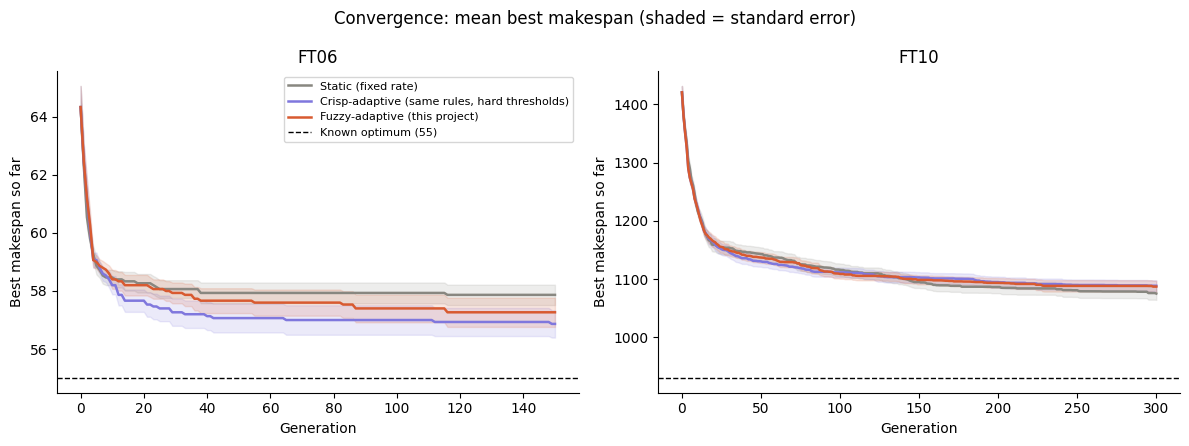

In [30]:
from jssp_fuzzy_ga.plotting import plot_convergence, plot_final_boxplot

data = {
    "ft06": {
        "static": {"curves": curves_static, "finals": finals_static},
        "crisp":  {"curves": curves_crisp,  "finals": finals_crisp},
        "fuzzy":  {"curves": curves_fuzzy,  "finals": finals_fuzzy},
    },
    "ft10": {
        "static": {"curves": curves_static10, "finals": finals_static10},
        "crisp":  {"curves": curves_crisp10,  "finals": finals_crisp10},
        "fuzzy":  {"curves": curves_fuzzy10,  "finals": finals_fuzzy10},
    },
}

fig1 = plot_convergence(data, instances=("ft06", "ft10"), out_path="convergence_comparison.png")
fig1

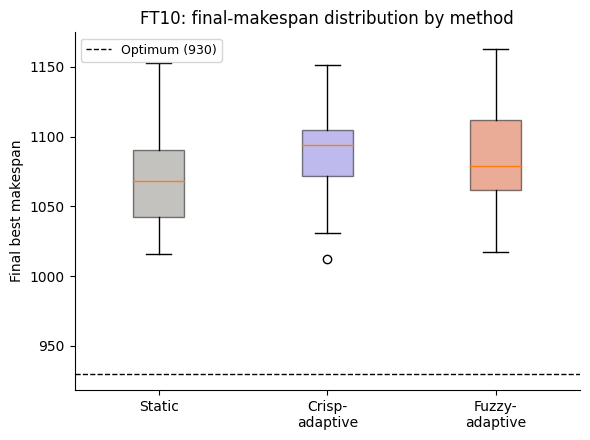

In [32]:
fig2 = plot_final_boxplot(data, instance="ft10", out_path="ft10_final_boxplot.png")
fig2

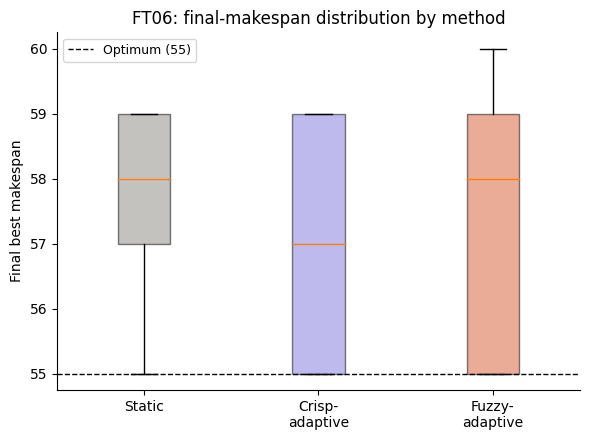

In [34]:
fig3 = plot_final_boxplot(data, instance="ft06", out_path="ft06_final_boxplot.png")
fig3